In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#fafafa",
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

with open("results/preliminary_experiment.json", "r", encoding="utf-8") as f:
    data = json.load(f)

tests = [t for t in data["tests"] if "error" not in t and t.get("t_delaunay") is not None]

resolutions = np.array([t["resolution"] for t in tests])
fills       = np.array([t["fill_ratio"] for t in tests])
n_points    = np.array([t["n_points"] for t in tests])
t_bc        = np.array([t["t_box_counting"] for t in tests])
t_td        = np.array([t["t_delaunay"] for t in tests])
t_total     = np.array([t["t_total"] for t in tests])
d_bc        = np.array([t["dim_bc"] for t in tests])
d_td        = np.array([t["dim_td"] for t in tests])

sparse = fills < 0.2
dense  = ~sparse

print(f"Система: {data['system_info']['os']}")
print(f"CPU: {data['system_info']['processor']}")
print(f"RAM: {data['system_info'].get('ram_total_gb', 'N/A')} GB")
print(f"Загружено {len(tests)} точек данных")

Система: Windows-11-10.0.26200-SP0
CPU: AMD64 Family 23 Model 104 Stepping 1, AuthenticAMD
RAM: 7.3 GB
Загружено 10 точек данных


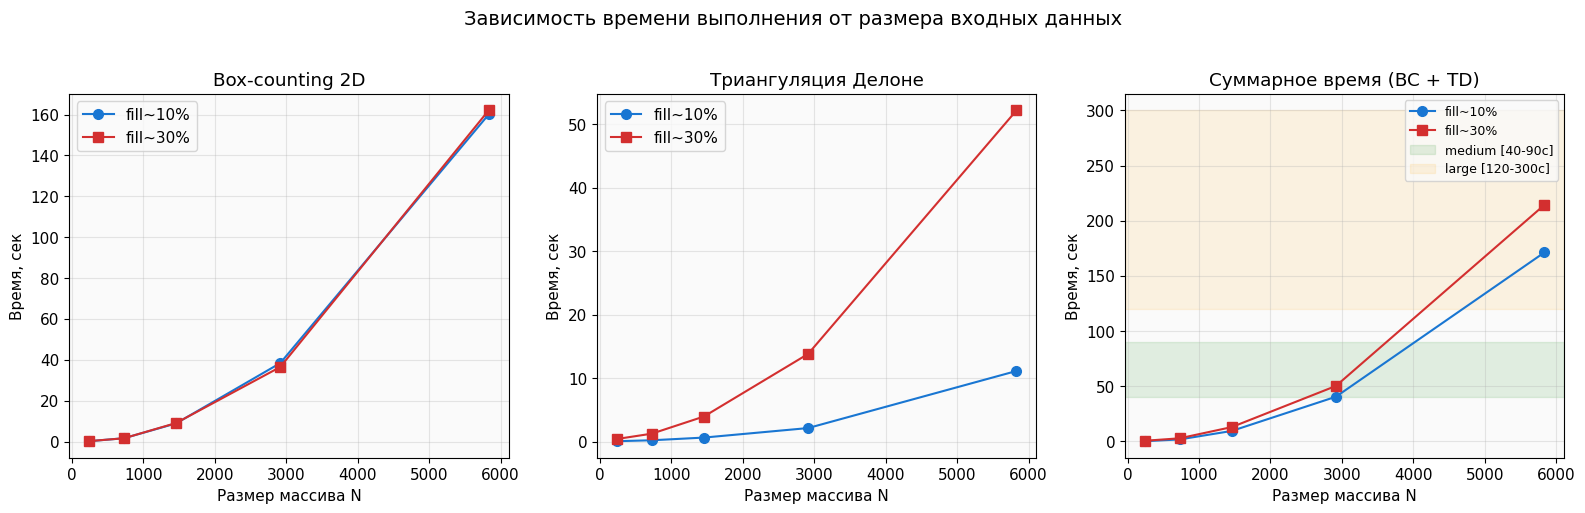

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.plot(resolutions[sparse], t_bc[sparse], "o-", color="#1976D2", label=f"fill~{fills[sparse][0]:.0%}", markersize=7)
ax.plot(resolutions[dense],  t_bc[dense],  "s-", color="#D32F2F", label=f"fill~{fills[dense][0]:.0%}", markersize=7)
ax.set_xlabel("Размер массива N")
ax.set_ylabel("Время, сек")
ax.set_title("Box-counting 2D")
ax.legend()

ax = axes[1]
ax.plot(resolutions[sparse], t_td[sparse], "o-", color="#1976D2", label=f"fill~{fills[sparse][0]:.0%}", markersize=7)
ax.plot(resolutions[dense],  t_td[dense],  "s-", color="#D32F2F", label=f"fill~{fills[dense][0]:.0%}", markersize=7)
ax.set_xlabel("Размер массива N")
ax.set_ylabel("Время, сек")
ax.set_title("Триангуляция Делоне")
ax.legend()

ax = axes[2]
ax.plot(resolutions[sparse], t_total[sparse], "o-", color="#1976D2", label=f"fill~{fills[sparse][0]:.0%}", markersize=7)
ax.plot(resolutions[dense],  t_total[dense],  "s-", color="#D32F2F", label=f"fill~{fills[dense][0]:.0%}", markersize=7)
ax.axhspan(40, 90, alpha=0.1, color="green", label="medium [40-90с]")
ax.axhspan(120, 300, alpha=0.1, color="orange", label="large [120-300с]")
ax.set_xlabel("Размер массива N")
ax.set_ylabel("Время, сек")
ax.set_title("Суммарное время (BC + TD)")
ax.legend(fontsize=9)

fig.suptitle("Зависимость времени выполнения от размера входных данных", fontsize=14, y=1.02)
fig.tight_layout()
plt.savefig("results/time_vs_resolution.png", dpi=150, bbox_inches="tight")
plt.show()

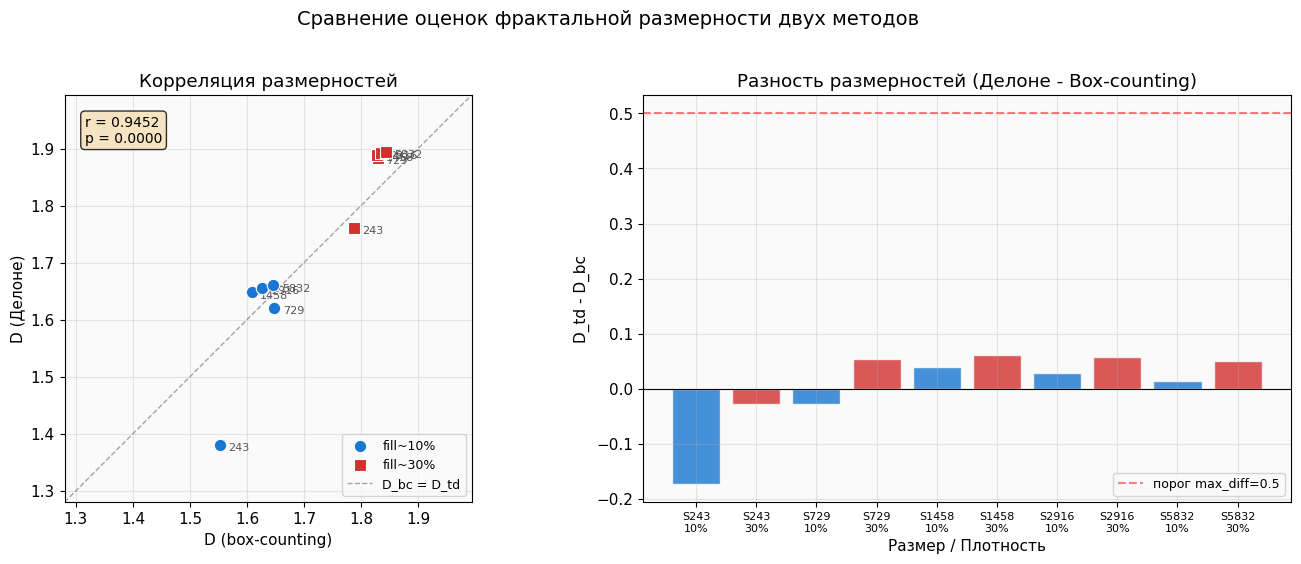


Корреляция Пирсона: r = 0.9452, p-value = 0.0000
Средняя разность D_td - D_bc: 0.0080 +/- 0.0676


In [12]:
from scipy.stats import pearsonr

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
ax.scatter(d_bc[sparse], d_td[sparse], c="#1976D2", s=80, zorder=5,
           label=f"fill~{fills[sparse][0]:.0%}", edgecolors="white", linewidth=0.8)
ax.scatter(d_bc[dense],  d_td[dense],  c="#D32F2F", s=80, zorder=5,
           label=f"fill~{fills[dense][0]:.0%}", edgecolors="white", linewidth=0.8, marker="s")

lims = [min(d_bc.min(), d_td.min()) - 0.1, max(d_bc.max(), d_td.max()) + 0.1]
ax.plot(lims, lims, "--", color="gray", alpha=0.7, label="D_bc = D_td", linewidth=1)

for i in range(len(tests)):
    ax.annotate(f"{resolutions[i]}", (d_bc[i], d_td[i]),
                textcoords="offset points", xytext=(6, -4), fontsize=8, color="#555")

ax.set_xlabel("D (box-counting)")
ax.set_ylabel("D (Делоне)")
ax.set_title("Корреляция размерностей")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_aspect("equal")
ax.legend(fontsize=9)

r, p_val = pearsonr(d_bc, d_td)
ax.text(0.05, 0.95, f"r = {r:.4f}\np = {p_val:.4f}",
        transform=ax.transAxes, fontsize=10, va="top",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

ax = axes[1]
diff = d_td - d_bc
colors = ["#1976D2" if s else "#D32F2F" for s in sparse]
x_labels = [f"S{r}\n{f:.0%}" for r, f in zip(resolutions, fills)]
ax.bar(range(len(diff)), diff, color=colors, alpha=0.8, edgecolor="white")
ax.set_xticks(range(len(diff)))
ax.set_xticklabels(x_labels, fontsize=8)
ax.set_xlabel("Размер / Плотность")
ax.set_ylabel("D_td - D_bc")
ax.set_title("Разность размерностей (Делоне - Box-counting)")
ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(0.5, color="red", linestyle="--", alpha=0.5, label="порог max_diff=0.5")
ax.legend(fontsize=9)

fig.suptitle("Сравнение оценок фрактальной размерности двух методов", fontsize=14, y=1.02)
fig.tight_layout()
plt.savefig("results/dimension_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nКорреляция Пирсона: r = {r:.4f}, p-value = {p_val:.4f}")
print(f"Средняя разность D_td - D_bc: {diff.mean():.4f} +/- {diff.std():.4f}")

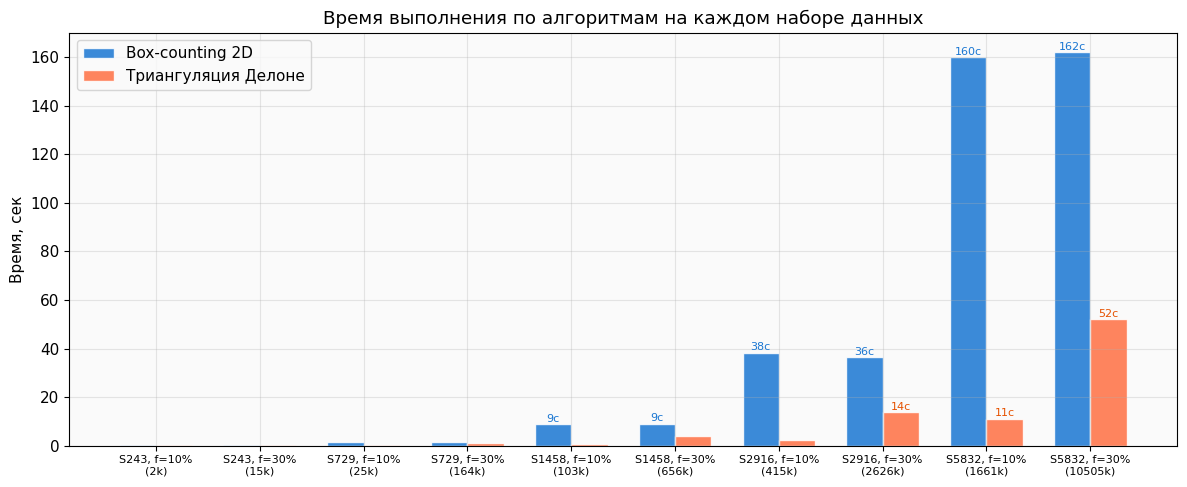

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(tests))
width = 0.35

bars1 = ax.bar(x - width/2, t_bc, width, label="Box-counting 2D",
               color="#1976D2", alpha=0.85, edgecolor="white")
bars2 = ax.bar(x + width/2, t_td, width, label="Триангуляция Делоне",
               color="#FF7043", alpha=0.85, edgecolor="white")

for bar in bars1:
    h = bar.get_height()
    if h > 5:
        ax.text(bar.get_x() + bar.get_width()/2, h + 1, f"{h:.0f}с",
                ha="center", fontsize=8, color="#1976D2")
for bar in bars2:
    h = bar.get_height()
    if h > 5:
        ax.text(bar.get_x() + bar.get_width()/2, h + 1, f"{h:.0f}с",
                ha="center", fontsize=8, color="#E65100")

labels = [f"S{r}, f={f:.0%}\n({n//1000}k)" for r, f, n in zip(resolutions, fills, n_points)]
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("Время, сек")
ax.set_title("Время выполнения по алгоритмам на каждом наборе данных")
ax.legend()

fig.tight_layout()
plt.savefig("results/time_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()

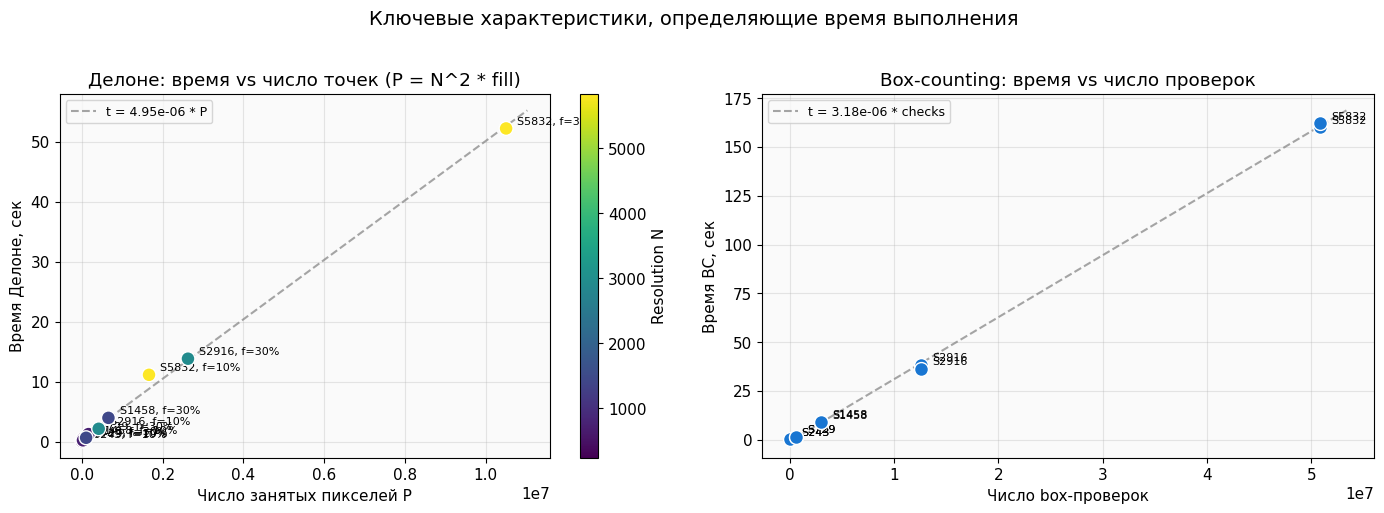

Делоне: t ~ 4.95e-06 * P (линейная зависимость от числа точек)
Box-counting: t ~ 3.18e-06 * checks (линейная зависимость от числа проверок)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sc = ax.scatter(n_points, t_td, c=resolutions, cmap="viridis", s=100, zorder=5, edgecolors="white")
for i in range(len(tests)):
    ax.annotate(f"S{resolutions[i]}, f={fills[i]:.0%}", (n_points[i], t_td[i]),
                textcoords="offset points", xytext=(8, 3), fontsize=8)

from numpy.polynomial.polynomial import polyfit
coeffs = polyfit(n_points, t_td, 1)
x_fit = np.linspace(0, n_points.max() * 1.05, 100)
y_fit = coeffs[0] + coeffs[1] * x_fit
ax.plot(x_fit, y_fit, "--", color="gray", alpha=0.7, label=f"t = {coeffs[1]:.2e} * P")
ax.set_xlabel("Число занятых пикселей P")
ax.set_ylabel("Время Делоне, сек")
ax.set_title("Делоне: время vs число точек (P = N^2 * fill)")
ax.legend(fontsize=9)
plt.colorbar(sc, ax=ax, label="Resolution N")

ax = axes[1]
box_checks = []
for r in resolutions:
    checks = sum((r // d) ** 2 for d in range(1, r // 2 + 1) if r % d == 0)
    box_checks.append(checks)
box_checks = np.array(box_checks)

ax.scatter(box_checks, t_bc, c="#1976D2", s=100, zorder=5, edgecolors="white")
for i in range(len(tests)):
    ax.annotate(f"S{resolutions[i]}", (box_checks[i], t_bc[i]),
                textcoords="offset points", xytext=(8, 3), fontsize=8)

coeffs_bc = polyfit(box_checks, t_bc, 1)
x_fit_bc = np.linspace(0, box_checks.max() * 1.05, 100)
y_fit_bc = coeffs_bc[0] + coeffs_bc[1] * x_fit_bc
ax.plot(x_fit_bc, y_fit_bc, "--", color="gray", alpha=0.7, label=f"t = {coeffs_bc[1]:.2e} * checks")
ax.set_xlabel("Число box-проверок")
ax.set_ylabel("Время BC, сек")
ax.set_title("Box-counting: время vs число проверок")
ax.legend(fontsize=9)

fig.suptitle("Ключевые характеристики, определяющие время выполнения", fontsize=14, y=1.02)
fig.tight_layout()
plt.savefig("results/performance_factors.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Делоне: t ~ {coeffs[1]:.2e} * P (линейная зависимость от числа точек)")
print(f"Box-counting: t ~ {coeffs_bc[1]:.2e} * checks (линейная зависимость от числа проверок)")

In [10]:
print(f"{'Набор':<16} {'N':>6} {'Fill':>5} {'Точки':>10} "
      f"{'BC,с':>8} {'TD,с':>8} {'Итого':>8} "
      f"{'D_bc':>7} {'D_td':>7} {'|diff|':>7}")
print("-" * 95)
for t in tests:
    diff = abs(t["dim_bc"] - t["dim_td"])
    name = f"S{t['resolution']}_f{int(t['fill_ratio']*100):02d}"
    print(f"{name:<16} {t['resolution']:>6} {t['fill_ratio']:>5.2f} {t['n_points']:>10,} "
          f"{t['t_box_counting']:>8.1f} {t['t_delaunay']:>8.1f} {t['t_total']:>8.1f} "
          f"{t['dim_bc']:>7.4f} {t['dim_td']:>7.4f} {diff:>7.4f}")

Набор                 N  Fill      Точки     BC,с     TD,с    Итого    D_bc    D_td  |diff|
-----------------------------------------------------------------------------------------------
S243_f10            243  0.10      2,732      0.2      0.1      0.3  1.5523  1.3801  0.1722
S243_f30            243  0.30     15,594      0.2      0.4      0.6  1.7881  1.7609  0.0272
S729_f10            729  0.10     25,962      1.6      0.2      1.8  1.6481  1.6212  0.0269
S729_f30            729  0.30    164,146      1.6      1.3      2.9  1.8290  1.8833  0.0543
S1458_f10          1458  0.10    103,848      8.9      0.7      9.5  1.6086  1.6477  0.0391
S1458_f30          1458  0.30    656,584      9.0      4.0     13.0  1.8281  1.8894  0.0613
S2916_f10          2916  0.10    415,392     38.4      2.2     40.5  1.6270  1.6556  0.0286
S2916_f30          2916  0.30  2,626,336     36.5     13.8     50.3  1.8353  1.8931  0.0578
S5832_f10          5832  0.10  1,661,568    160.1     11.2    171.2  1.6464 